# Import

In [1]:
import os
import glob
from itertools import product
import numpy as np
import graphical_sampling as gs
import pandas as pd
from tqdm import tqdm

/home/bardia/graphical-sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "PWD" redefined by R and overriding existing variable. Current: "/home/bardia/graphical-sampling", R: "/home/bardia/graphical-sampling/simulations/Store/jupyter"
  warnings.warn(
/home/bardia/graphical-sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/bardia/graphical-sampling/.venv/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_PAPERSIZE_USER" redefined by R and overriding existing variable. Current: "a4"

# NHT Variance

In [2]:
N = 100
n = 4
num_zones = 4
rng = gs.random.rng()
coords = rng.rand_coord((N, 2))
variable = np.random.rand(N) * 10
# inclusions = rng.unequal_inclusions(n, N)
inclusions = variable + np.random.rand(N)
pop = gs.Population(coords, inclusions, n=n, variable=variable)

In [9]:
# df = pd.read_csv('populations/MU284_filtered.csv')
# cs82 = df['CS82'].values.astype(float)
# rmt85 = df['RMT85'].values.astype(float)
# ss82 = df['SS82'].values.astype(float)

# N = len(df)
# n = 10
# num_zones = 4
# rng = gs.random.rng()
# coords = rng.rand_coord((N, 2))
# pop = gs.Population(
#     coords=rng.rand_coord((N, 2)),
#     inclusions=ss82,
#     variable=cs82,
#     n=4
# )

In [11]:
initial_designs = [gs.Design(pop, num_partitions=num_zones) for _ in range(100)]
criteria = gs.criteria.VarNHT()
gbfs = gs.search.GreedyBestFirstSearch(initial_designs, criteria)

In [12]:
gbfs.run(
    max_iterations=1000,
    max_open_set_size=2000,
    top_k=10,
    num_new_order_nodes=0,
    num_new_exchange_nodes=5,
    num_clusters=2,
    num_zones=1,
    num_changes=2,
    num_zone_changes=1,
    random_pull=True,
    exchange_coef=1.0,
    num_explore=5
)

TypeError: GreedyBestFirstSearch.run() got an unexpected keyword argument 'random_pull'

# Spread

## Random Population

In [3]:
N = 1000
n = 4
num_zones = 4
rng = gs.random.rng()
coords = rng.rand_coord((N, 2))
variable = np.random.rand(N) * 10
# inclusions = rng.unequal_inclusions(n, N)
inclusions = variable + np.random.rand(N)
pop = gs.Population(coords, inclusions, n=n, variable=variable)

<Axes: title={'center': 'FIP Balanced 4-Means Soft Clustering with Zones'}, xlabel='$X_1$', ylabel='$X_2$'>

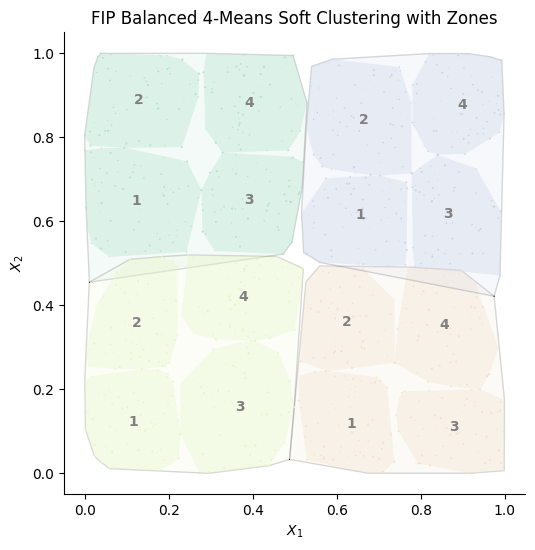

In [4]:
fbn = gs.clustering.FIPBalancedNMeans(n)
fbn.fit(pop)
fbn.fit_zones(num_zones=(2, 2), mode='sweep_xy')
fbn.plot(mode='soft')

## Paper Population

In [5]:
DATA_DIR = "/home/bardia/graphical-sampling/populations"

csv_paths = glob.glob(os.path.join(DATA_DIR, "*.csv"))

coords_dict = {}
probs_dict = {}

for fp in csv_paths:
    print(fp)
    name = os.path.splitext(os.path.basename(fp))[0]
    data = np.loadtxt(fp, delimiter=",", skiprows=1)
    print(name)
    coords = data[:, :2]
    probs  = data[:, -1]
    print(probs)
    coord_name, prob_name, *rest = name.split("_")
    coord_name = 'cluster' if coord_name == 'clust' else coord_name
    prob_name = 'equal' if prob_name == 'eq' else 'unequal'

    coords_dict[coord_name] = coords
    probs_dict[coord_name] = probs_dict.get(coord_name, {})
    probs_dict[coord_name][prob_name] = probs

print(coords_dict.keys())

dict_keys([])


In [13]:
dfs ={}
# /config/ws/graphical-sampling/simulations/populations/real
path = "../populations/real"
files = ["aggregated.csv", "regular.csv", "meuse.csv", "swiss.csv"]

def popus(n):
    for f in files:
        full_path = os.path.join(path, f)
        df = pd.read_csv(full_path)
        N = len(df)
        
        if f in ["aggregated.csv", "regular.csv"]:
            coords = df.iloc[:, :].to_numpy()
            probs_ep  = np.repeat(n/N, N)
            name = f.replace('.csv', '')
            dfs[f'df_{name}'] = pd.DataFrame(
                {'coord_x':coords[:,0],
                'coord_y':coords[:,1],
                'pik_ep' : probs_ep,}
                )
        ##################################
        if f == "meuse.csv":
            coords = df[['x', 'y']].to_numpy()
            probs_up  = inclusion_probabilities(df['copper'].to_numpy(), n)
            probs_ep  = np.repeat(n/N, N)
            name = f.replace('.csv', '')
            dfs[f'df_{name}'] = pd.DataFrame(
                {'coord_x':coords[:,0],
                'coord_y':coords[:,1],
                'pik_ep' : probs_ep,
                'pik_up' : probs_up,
                'z'      : df['cadmium'], }
                )
        ###################################
        if f == "swiss.csv":
            coords = df[['x', 'y']].to_numpy()
            AREA = df['AREA'].to_numpy().clip(5,100)
            probs_up  = inclusion_probabilities(AREA, n)
            probs_ep  = np.repeat(n/N, N)
            name = f.replace('.csv', '')
            dfs[f'df_{name}'] = pd.DataFrame(
                {'coord_x':coords[:,0],
                'coord_y':coords[:,1],
                'pik_ep' : probs_ep,
                'pik_up' : probs_up,
                'z'      : df['AREA_A'].to_numpy(), }
                )
        ####################################
    return(dfs)


In [15]:

df = popus(n)[df_regular]
N = len(df)

coords = pd.DataFrame(df[['coord_x', 'coord_y']])
inclusions = df[ep_or_up]
variable = df['z'] if 'z' in df.columns else inclusions

# pop = gs.Population(coords, inclusions, n=n, variable=variable)
# fbn = gs.clustering.FIPBalancedNMeans(n=n, init_clust_method = 'expanded', split_size = 1)


N = len(probs)
n = 4
num_zones = 4
pop = gs.Population(coords, probs, n=n)

FileNotFoundError: [Errno 2] No such file or directory: '../populations/real/aggregated.csv'

In [ ]:
initial_designs = []
point_strategies = [
    None, 'lexico_xy', 'lexico_yx', 'angle', 'dist_from_origin',
    'projection', 'dist_from_centroids', 'max_coord', 'spiral'
]
zone_strategies = [
    None, 'lexico_xy', 'lexico_yx', 'dist_from_origin', 'projection', 'spiral'
]
zone_modes = [
    'cluster', 'sweep_xy', 'sweep_yx'
]
num_zones_cluster = [4]
num_zones_sweep = [(2, 2)]
num_splits = [4]
track = []
num_designs = len(point_strategies) * len(zone_strategies) * len(zone_modes) * len(num_splits)
for point_strategy, zone_strategy, zone_mode, num_split in tqdm(
    product(point_strategies, zone_strategies, zone_modes, num_splits), total=num_designs
):
    if zone_mode == 'cluster':
        list_of_num_zones = num_zones_cluster
    else:
        list_of_num_zones = num_zones_sweep
    for num_zones in list_of_num_zones:
        for _ in range(1):
            fbn = gs.clustering.FIPBalancedNMeans(n)
            fbn.fit(pop)
            fbn.fit_zones(num_zones=num_zones, mode=zone_mode)
            design = gs.Design.from_order(
                pop,
                order=gs.Order.from_clusters(pop, fbn.clusters, point_strategy, zone_strategy, num_split),
            )
            initial_designs.append(design)
            # print(strategy, zone_mode, num_partitions, design.moran[0])
            track.append((design.moran[0], zone_strategy, point_strategy, zone_mode, num_zones))

100%|██████████| 162/162 [00:50<00:00,  3.19it/s]


In [ ]:
z = sorted(track, key=lambda x: x[0], reverse=False)
z[:10]

[(-0.085336523403093, 'lexico_yx', 'projection', 'sweep_yx', (2, 2)),
 (-0.08470723764689794, 'lexico_yx', None, 'sweep_yx', (2, 2)),
 (-0.08447566590690223, 'lexico_yx', 'spiral', 'sweep_yx', (2, 2)),
 (-0.0843829003097672, 'spiral', None, 'sweep_yx', (2, 2)),
 (-0.0843829003097672, 'spiral', 'projection', 'sweep_yx', (2, 2)),
 (-0.0841712601821149, 'lexico_xy', 'spiral', 'cluster', 4),
 (-0.084077744926908, 'projection', None, 'sweep_yx', (2, 2)),
 (-0.08396989982531844, 'dist_from_origin', 'spiral', 'sweep_yx', (2, 2)),
 (-0.08382623742945805, 'dist_from_origin', None, 'sweep_yx', (2, 2)),
 (-0.08362984668073584, 'projection', 'projection', 'sweep_yx', (2, 2))]

In [ ]:
criteria = gs.criteria.MoranCriteria()
gbfs = gs.search.GreedyBestFirstSearch(initial_designs, criteria)

In [ ]:
gbfs.run(
    max_iterations=2000,
    max_open_set_size=1000,
    top_k=1,
    num_new_order_nodes=10,
    num_new_exchange_nodes=0,
    num_clusters=1,
    num_zones=1,
    num_changes=1,
    num_zone_changes=0,
    pull_strategy='default',
    exchange_coef=0.75,
    num_explore=1
)

--- Starting Parallel GBFS: Max Iterations=2000, Batch Size=1, Workers=-1 ---
Initial best criteria value: -0.0853
Iter     0/2000 | Best: -0.0853 | Open:   162 | Closed:     0
  [!] New best found at iter 0: -0.0861 (improved by 0.0007)
  [!] New best found at iter 1: -0.0866 (improved by 0.0005)
  [!] New best found at iter 2: -0.0866 (improved by 0.0000)
  [!] New best found at iter 2: -0.0867 (improved by 0.0000)
  [!] New best found at iter 3: -0.0867 (improved by 0.0001)
  [!] New best found at iter 4: -0.0868 (improved by 0.0000)
  [!] New best found at iter 5: -0.0868 (improved by 0.0001)
  [!] New best found at iter 6: -0.0868 (improved by 0.0000)
  [!] New best found at iter 6: -0.0868 (improved by 0.0000)
  [!] New best found at iter 6: -0.0869 (improved by 0.0000)
  [!] New best found at iter 7: -0.0869 (improved by 0.0000)
  [!] New best found at iter 8: -0.0869 (improved by 0.0000)
  [!] New best found at iter 9: -0.0871 (improved by 0.0002)
  [!] New best found at iter 1

KeyboardInterrupt: 